In [1]:
from __future__ import annotations

import logging as lgr
import os
from dataclasses import dataclass
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch as th
from matplotlib.axes import Axes
from matplotlib.figure import Figure

In [2]:
pltcfg_p: str = "conf/20260117-baseline.yaml"

In [3]:
@dataclass
class PlotConf:
    title: Optional[str]
    key: str
    expcfgs: list[ExpConf]


@dataclass
class ExpConf:
    subtitle: str
    exp_ps: dict[str, str]  # afa method to experiment path
    runtime_ps: dict[str, str]
    xlim: tuple[Optional[float], Optional[float]]
    ylim_row0: tuple[Optional[float], Optional[float]]

In [4]:
lgrkeys_to_ylabel = {
    "acc": "accuracy",
    "f1-score": "f1-score",
}
method_to_cfgkey = {
    # "make_templates_vanilla": "greedy",
    "make_templates_fix_rounds": "tafa-mutate-knn",
    # "tafa-dagger-dtc-make_templates_vanilla": "",
    "tafa-dagger-dtc-make_templates_fix_rounds": "tafa-interp.",
    # "make_templates_reduce_features": "tafa-reduce-search",
    # "dagger-make_templates_vanilla": "greedy-dagger",
    # "dagger-make_templates_fix_rounds": "mutate-dagger",
    # "dagger-make_templates_reduce_features": "tafa-reduce-search-dagger",
    # "dropout-make_templates_vanilla": "greedy-dropout",
    # "dropout-make_templates_fix_rounds": "mutate-dropout",
}
cfgkey_to_plot_kwargs = {
    "tafa-gumbel-knn": {
        "label": "tafa",
        "color": "r",
        "alpha": 0.5,
        "marker": ".",
        "markersize": 10,
        "linewidth": 3,
    },
    # "tafa-knn": {
    #     "color": "lime",
    #     "alpha": 0.8,
    #     "marker": ".",
    #     "markersize": 6,
    # },
    "tafa-gumbel": {
        "color": "darkred",
        "alpha": 0.5,
        "marker": ".",
        "markersize": 10,
        "linewidth": 3,
    },
    "tafa-interp.": {
        "color": "crimson",
        "alpha": 0.5,
        "marker": ".",
        "markersize": 10,
        "linewidth": 3,
    },
    "aco": {
        "color": "b",
        "alpha": 0.5,
        "marker": ".",
        "markersize": 10,
        "linewidth": 3,
    },
    "dime": {
        "color": "y",
        "alpha": 0.5,
        "marker": ".",
        "markersize": 10,
        "linewidth": 3,
    },
    "jafa": {
        "color": "m",
        "alpha": 0.5,
        "marker": ".",
        "markersize": 10,
        "linewidth": 3,
    },
    "sefa": {
        "color": "c",
        "alpha": 0.5,
        "marker": ".",
        "markersize": 10,
        "linewidth": 3,
    },
    "static": {
        "color": "darkorange",
        "alpha": 0.5,
        "marker": ".",
        "markersize": 10,
        "linewidth": 3,
    },
}
# "color": "blue"
# "color": "red"
# "color": "purple"
# "color": "gold"
# "color": "darkgreen"
# "color": "lime"
# "color": "cyan"
# "color": "magenta"
# "color": "blueviolet"
# "color": "darkorange"
# "color": "tan"

In [5]:
def make_plots(
    pltcfg: PlotConf,
    metrics_dl: list[dict[str, list[pd.DataFrame]]],
    runtimes_dl: list[dict[str, pd.DataFrame]],
):
    fig: Figure
    axs: list[list[Axes]]
    fig, axs = plt.subplots(
        nrows=2,
        ncols=len(pltcfg.expcfgs),
        squeeze=False,
        layout="constrained",
        sharex="col",
    )  # type:ignore
    label_set = list()
    line_set = list()
    for _expcfg, _ax, _metrics_d in zip(pltcfg.expcfgs, axs[0], metrics_dl):
        _ax.set_title(_expcfg.subtitle, fontsize=23)
        _ax.set_box_aspect(1.0)
        for _name, _metrics_dfl in reversed(_metrics_d.items()):
            if len(_metrics_dfl) == 0:
                continue
            _prefix: str
            if "eval/acc" in _metrics_dfl[0]:
                _prefix = "eval"
            elif "eval_val/acc" in _metrics_dfl[0]:
                _prefix = "eval_val"
            elif "eval_dagger/acc" in _metrics_dfl[0]:
                _prefix = "eval_dagger"
            else:
                lgr.warning(f"{_name} has unsupported metrics key")
                continue
            _data = pd.concat(
                [
                    _mdf[
                        [f"{_prefix}/feature observed", f"{_prefix}/{pltcfg.key}"]
                    ].dropna()
                    for _mdf in _metrics_dfl
                ]
            ).to_numpy()
            _data = _data[np.argsort(_data[:, 0]).flatten()]
            _ax.plot(
                _data[:, 0],
                _data[:, 1],
                # label=_name,
                # marker="x",
                **{
                    **(
                        {"label": _name}
                        if "label" not in cfgkey_to_plot_kwargs[_name]
                        else {}
                    ),
                    **cfgkey_to_plot_kwargs[_name],
                },
            )
        _ax_lines, _ax_labels = _ax.get_legend_handles_labels()
        for _ax_line, _ax_label in zip(_ax_lines, _ax_labels):
            if _ax_label not in label_set:
                line_set.append(_ax_line)
                label_set.append(_ax_label)
        _xlim, _ylim = [*_ax.get_xlim()], [*_ax.get_ylim()]
        _xlim[0] = _xlim[0] if _expcfg.xlim[0] is None else _expcfg.xlim[0]
        _xlim[1] = _xlim[1] if _expcfg.xlim[1] is None else _expcfg.xlim[1]
        _ax.set_xlim(*_xlim)
        _ylim[0] = _ylim[0] if _expcfg.ylim_row0[0] is None else _expcfg.ylim_row0[0]
        _ylim[1] = _ylim[1] if _expcfg.ylim_row0[1] is None else _expcfg.ylim_row0[1]
        _ax.set_ylim(*_ylim)
        # _ax.yaxis.set_major_formatter(
        #     FormatStrFormatter("%.3f")
        #     if abs(_ylim[1] - _ylim[0]) < 0.01
        #     else FormatStrFormatter("%.2f")
        # )
    for _expcfg, _ax, _runtimes_d in zip(pltcfg.expcfgs, axs[1], runtimes_dl):
        # _ax.set_title(_expcfg.subtitle)
        _ax.set_box_aspect(1.0)
        for _name, _runtimes_df in reversed(_runtimes_d.items()):
            if len(_runtimes_df) == 0:
                continue
            _ax.plot(
                _runtimes_df["eval/feature observed"],
                _runtimes_df["eval/avg_pred_time_ns"] * 1e-9,
                **{
                    **(
                        {"label": _name}
                        if "label" not in cfgkey_to_plot_kwargs[_name]
                        else {}
                    ),
                    **cfgkey_to_plot_kwargs[_name],
                },
            )
        _ax_lines, _ax_labels = _ax.get_legend_handles_labels()
        for _ax_line, _ax_label in zip(_ax_lines, _ax_labels):
            if _ax_label not in label_set:
                line_set.append(_ax_line)
                label_set.append(_ax_label)
        _xlim, _ylim = [*_ax.get_xlim()], [*_ax.get_ylim()]
        _xlim[0] = _xlim[0] if _expcfg.xlim[0] is None else _expcfg.xlim[0]
        _xlim[1] = _xlim[1] if _expcfg.xlim[1] is None else _expcfg.xlim[1]
        _ax.set_xlim(*_xlim)
        _ylim[0] = _ylim[0] if _expcfg.ylim_row0[0] is None else _expcfg.ylim_row0[0]
        _ylim[1] = _ylim[1] if _expcfg.ylim_row0[1] is None else _expcfg.ylim_row0[1]
        # _ax.set_ylim(*_ylim)
        _ax.set_yscale("log")
    return fig, axs, line_set, label_set, metrics_dl, runtimes_dl

In [6]:
_tmp = th.load(os.path.join("outputs", "baseline_metrics.pt"), weights_only=False)

pltcfg: PlotConf = _tmp["pltcfg"]
metrics_dl: list[dict[str, list[pd.DataFrame]]] = _tmp["metrics_dl"]
runtimes_dl: list[dict[str, pd.DataFrame]] = _tmp["runtimes_dl"]

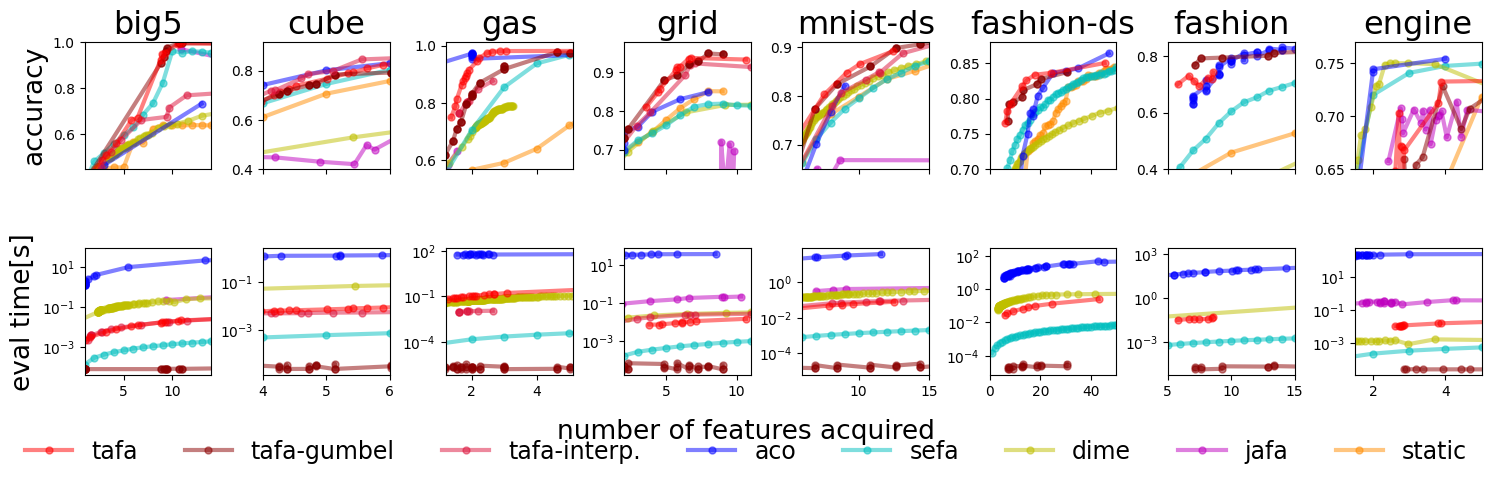

In [7]:
fig, axs, line_set, label_set, metrics_dl, runtimes_dl = make_plots(
    pltcfg=pltcfg, metrics_dl=metrics_dl, runtimes_dl=runtimes_dl
)
fig.set_figheight(1.75 * 2.0 + 0.667 * max(len(label_set) // 4 - 1, 0) + 0.6)
fig.set_figwidth(1.85 * len(axs[0]))
if pltcfg.title is not None:
    fig.suptitle(pltcfg.title)
fig.supxlabel("number of features acquired\n", fontsize=19)
# fig.supylabel(keys_to_ylabel[pltcfg.key])
axs[0][0].set_ylabel(lgrkeys_to_ylabel[pltcfg.key], fontsize=19)
axs[1][0].set_ylabel("eval time[s]", fontsize=19)
fig.legend(
    list(reversed(line_set)),
    list(reversed(label_set)),
    loc="outside lower center",
    frameon=False,
    ncol=10,
    # ncol=6,
    fontsize=17,
    # borderaxespad=1.0,
    # borderaxespad=0.18,
)
fn: str = os.path.splitext(pltcfg_p.split("/")[-1])[0]
os.makedirs("outputs", exist_ok=True)
fig.savefig(os.path.join("outputs", f"{fn}.png"), dpi=720, bbox_inches="tight")
plt.show()
plt.close()